# Machine learning project:
# Natural Language Processing with Disaster Tweets

In [1]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.tokenize import wordpunct_tokenize


from sklearn import feature_extraction, linear_model, model_selection
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

import tensorflow 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense 
from tensorflow.keras.utils import to_categorical 
from keras.utils.vis_utils import plot_model
from tensorflow.python.framework.random_seed import set_random_seed
from keras.callbacks import EarlyStopping

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 1. Data preparation

##### Load the data

In [2]:
train = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/train.csv", sep=",")
test = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/test.csv", sep=",")

In [3]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


##### Delete some useless columns 

In [4]:
train = train.drop(["id", "keyword", "location"],axis=1)

##### Replace some useless symbols, punctuations, links and so on with whitespace or nothing!

In [5]:
train.text = train.text.map(lambda x: re.sub("[\.\$\@\!\*\&\?\_\__\'\"\#\,\-\+\<\>\=\;]", "", x))
train.text = train.text.map(lambda x: re.sub("[\n]", " ", x))
train.text = train.text.map(lambda x: re.sub("()", "", x))
train.text = train.text.map(lambda x: re.sub("[0-9]", "", x))
train.text = train.text.map(lambda x: re.sub(r'http\S+', "", x))

##### Change uppercase letters to lowercase letters

In [6]:
train.text = train.text.map(lambda x: x.lower())

##### Delete some words from the data using "word_tokenize" and "stopwords"

In [7]:
train.text = train.text.map(lambda x: word_tokenize(x))

In [8]:

stopwords1 = stopwords.words('english')
extra_words = ["gtgt","via","rt","st","im","re","a","b","c","d","e","f","g","h","j","k","lol","l","m","n","o","p","q","r","s","t","u","v","w","x","y","z","ll","ve","tco","nt"]
stopwords1.extend(extra_words)

In [9]:
train.text = train.text.map(lambda x: (" ").join([word for word in x if not word in stopwords1]))



# 2. Check whether the data is balance or not

In [10]:
train.target.value_counts(sort=False)

1    3271
0    4342
Name: target, dtype: int64

### as you can see, the data is almost balanced. So, we don't need Undersampling or Oversampling here.

# 3. Split the data and vectorize it

In [11]:
# Report finding: classes are close to balanced, so we use a standard random split.
# Keep a fixed seed to make model comparisons reproducible.
X_train, X_val, y_train, y_val = train_test_split(train.text, train.target, train_size=0.75, random_state=123)
count_vectorizer = CountVectorizer()

# vectorize train set
X_tr_ve = count_vectorizer.fit_transform(X_train)
column_name = count_vectorizer.get_feature_names_out()
X_tr_vec = pd.DataFrame(X_tr_ve.toarray(),columns=column_name)

# vectorize validation set
X_val_ve = count_vectorizer.transform(X_val)
column_name = count_vectorizer.get_feature_names_out()
X_val_vec = pd.DataFrame(X_val_ve.toarray(),columns=column_name)

In [12]:
print(X_tr_vec.shape)
print(X_val_vec.shape)

(5709, 13996)
(1904, 13996)





# 4. Now we use different algorithms:
### 4.1. Logistic Regression

In [13]:
clf_lr = LogisticRegression()
clf_lr.fit(X_tr_vec, y_train)
y_train_pred_lr = clf_lr.predict(X_tr_vec)
y_val_pred_lr = clf_lr.predict(X_val_vec)
tr_acc = accuracy_score(y_train, y_train_pred_lr)
val_acc = accuracy_score(y_val, y_val_pred_lr)
print("accuracy for the train : {}, \naccuracy for the validation : {}".format(tr_acc,val_acc))

accuracy for the train : 0.9639166228761604, 
accuracy for the validation : 0.7951680672268907


### 4.2. Logistic Regression with different hyperparameters (Regularization hyperparameteres)


LR. C= 0.001.	Train ACC: 0.5685759327377824	Val Acc: 0.5761554621848739
LR. C= 0.01.	Train ACC: 0.7379576107899807	Val Acc: 0.7127100840336135
LR. C= 0.1.	Train ACC: 0.8737081800665616	Val Acc: 0.8004201680672269
LR. C= 0.5.	Train ACC: 0.9414958836924154	Val Acc: 0.7946428571428571
LR. C= 1.0.	Train ACC: 0.9639166228761604	Val Acc: 0.7951680672268907
LR. C= 1.5.	Train ACC: 0.9721492380451918	Val Acc: 0.7941176470588235
LR. C= 2.	Train ACC: 0.977579260816255	Val Acc: 0.7946428571428571
LR. C= 5.	Train ACC: 0.9861622000350324	Val Acc: 0.7830882352941176
LR. C= 10.	Train ACC: 0.9877386582588895	Val Acc: 0.7794117647058824


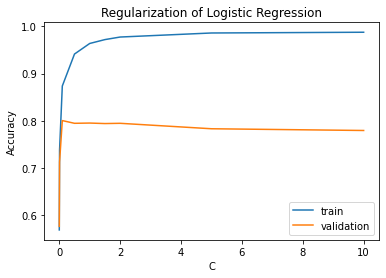

In [29]:
# Report finding: the best validation performance is reached around C=0.1.
# Higher C values continue improving train accuracy but start to overfit.
C = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2, 5, 10]
tr_acc=[]
val_acc=[]

for c in C:
    model_lr_op = LogisticRegression(C=c,max_iter = 200)
    model_lr_op.fit(X_tr_vec, y_train)
    y_train_pred_lr = model_lr_op.predict(X_tr_vec)
    y_val_pred_lr = model_lr_op.predict(X_val_vec)
    tr_acc.append(accuracy_score(y_train, y_train_pred_lr))
    val_acc.append(accuracy_score(y_val, y_val_pred_lr))
    print(f"LR. C= {c}.\tTrain ACC: {accuracy_score(y_train, y_train_pred_lr)}\tVal Acc: {accuracy_score(y_val, y_val_pred_lr)}")

fig = plt.figure(figsize=(6, 4))
plt.plot(C,tr_acc, label="train")
plt.plot(C,val_acc,label="validation")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Regularization of Logistic Regression")
plt.legend()
plt.show()

### 4.3. SVM with linear kernel

In [15]:
#we split the data again and use min_df to reduce the size of our features.otherwise, it would take too long to run svm. 
X_train, X_val, y_train, y_val = train_test_split(train.text, train.target, train_size=0.75, random_state=123)
count_vectorizer1 = CountVectorizer(min_df=3)

#vectorize train set
X_tr_ve_svm = count_vectorizer1.fit_transform(X_train)
X_tr_vec_svm = pd.DataFrame(X_tr_ve_svm.toarray())

#vectorize validation set
X_val_ve_svm = count_vectorizer1.transform(X_val)
X_val_vec_svm = pd.DataFrame(X_val_ve_svm.toarray())

In [16]:
X_tr_ve_svm.shape

(5709, 3384)

In [17]:
clf_svm = SVC(kernel='linear',C=1)
clf_svm.fit(X_tr_vec_svm, y_train)
y_train_pred_svm = clf_svm.predict(X_tr_vec_svm)
y_val_pred_svm = clf_svm.predict(X_val_vec_svm)
tr_acc = accuracy_score(y_train, y_train_pred_svm)
val_acc = accuracy_score(y_val, y_val_pred_svm)
print(f"SVM method with parameter C: 1\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

SVM method with parameter C: 1	Train ACC: 0.9332632685233841	Val Acc: 0.7757352941176471


### 4.4. SVM with RBF kernel (using GridSearchCV)

In [18]:
# Report finding: RBF-SVM is competitive, but still slightly below the best LR setup.
lr = SVC(random_state= 123)
svc_grid_params = {'C': (0.1, 1., 10), 'kernel': ['rbf'] ,'gamma': [0.1,1, 10]}
clf_RBF = GridSearchCV(lr, svc_grid_params, cv = 5)
clf_RBF.fit(X_tr_ve_svm, y_train)
y_train_pred_svm = clf_RBF.predict(X_tr_vec_svm)
y_val_pred_svm = clf_RBF.predict(X_val_vec_svm)
print("best Parameter is: {}".format(clf_RBF.best_params_))
print("best score is: {}".format(clf_RBF.best_score_))
print(f"SVC.\tTrain:{f1_score(y_train, y_train_pred_svm,average = 'macro'):.4f}\tVal:{f1_score(y_val, y_val_pred_svm,average = 'macro'):.4f}")
#print(f"SVC.\tTrain:{accuracy_score(y_train, y_train_pred_svm):.4f}\tVal:{accuracy_score(y_val, y_val_pred_svm):.4f}")

best Parameter is: {'C': 1.0, 'gamma': 0.1, 'kernel': 'rbf'}
best score is: 0.7964629914153406
SVC.	Train:0.9083	Val:0.7900


### 4.5. K-nearest neighbors 

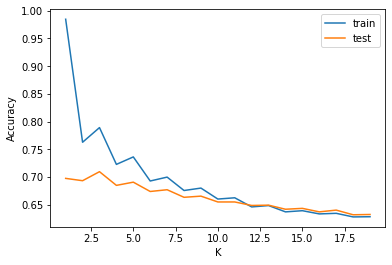

In [19]:
accuracy_values_train = []
accuracy_values_test = []
k_values = range(1, 20)

for k in k_values:
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(X_tr_vec, y_train)
    y_pred_train = model_knn.predict(X_tr_vec)
    y_pred_val = model_knn.predict(X_val_vec)
    accuracy_values_train.append(accuracy_score(y_pred_train, y_train))
    accuracy_values_test.append(accuracy_score(y_pred_val, y_val))
    
fig = plt.figure(figsize=(6, 4))
plt.plot(k_values, accuracy_values_train, label="train")
plt.plot(k_values, accuracy_values_test, label="test")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### 4.6. Neural Network

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                167560    
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 2)                 22        
                                                                 
Total params: 167,692
Trainable params: 167,692
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/50
357/357 [==============================] - 4s 8ms/step - loss: 0.6830 - accuracy: 0.5731 - val_loss: 0.6869 - val_accuracy: 0.5494
Epoch 2/50
357/357 [==============================] - 3s 8ms/step - loss: 0.6737 - accuracy: 0.5777 - val_loss: 0.6802 - val_accuracy: 0.5499
Epoch 3/50
357/357 [=====

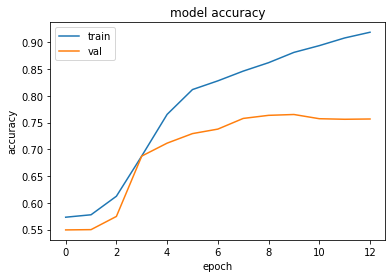

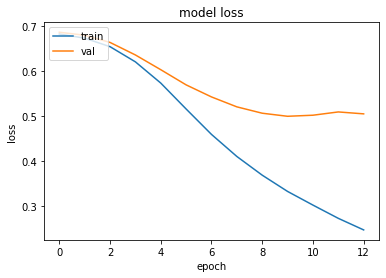

In [20]:
count_vectorizer2 = CountVectorizer()
X_tr_ve_nn = count_vectorizer2.fit_transform(train.text)
X_tr_vec_nn = pd.DataFrame(X_tr_ve_nn.toarray())
feature_vector_length = X_tr_vec_nn.shape[1]

num_classes = 2 
y_train_nn = to_categorical(train.target, num_classes)

# simple early stopping
es = EarlyStopping(monitor='val_loss', #quantity to be monitored
                   mode='min', #we look for decreasing patterns stop 
                   patience = 3, #number of epochs with no improvement
                   verbose=1)

np.random.seed(123)
set_random_seed(2)

clf1 = Sequential()  # we first define how the "model" looks like
clf1.add(Dense(input_dim=feature_vector_length, units=10, activation='relu'))  # input layer
clf1.add(Dense(units=10, activation='relu'))  # input layer
clf1.add(Dense(num_classes, activation='softmax'))  # output layer
print(clf1.summary())

# Configure the model and start training
clf1.compile(loss='categorical_crossentropy',  # loss metric
              optimizer='sgd',  # optimizer
              metrics=['accuracy'])  # displayed metric

history=clf1.fit(X_tr_vec_nn, y_train_nn, epochs=50, batch_size=16, verbose=1, validation_split=0.25, callbacks=[es])

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
# plt.ylim(0.8, 1)
plt.show()

# summarize history for accuracy
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
# plt.ylim(0.8, 1)
plt.show()

### 4.7. Decision Tree

In [21]:
# Report finding: Decision Trees strongly overfit here (very high train score, weaker validation score).
# We still keep this baseline for comparison with linear models.
dt_grid_params = {'criterion': ['entropy'], 'max_depth': (None, 3, 5, 10)}

dt_clf = DecisionTreeClassifier(random_state= 123)
dt_v1 = GridSearchCV(dt_clf, dt_grid_params, n_jobs= -1, cv = 5)
dt_v1.fit(X_tr_vec, y_train)


y_train_pred = dt_v1.predict(X_tr_vec)
y_val_pred = dt_v1.predict(X_val_vec)
print(f"Decision Tree.\tTrain:{f1_score(y_train, y_train_pred,average = 'macro'):.4f}\tVal:{f1_score(y_val, y_val_pred,average = 'macro'):.4f}")

print("best Parameter is: {}".format(dt_v1.best_params_))
print("best score is: {}".format(dt_v1.best_score_))

/usr/local/lib/python3.7/dist-packages/joblib/externals/loky/process_executor.py:705: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


Decision Tree.	Train:0.9880	Val:0.7437
best Parameter is: {'criterion': 'entropy', 'max_depth': None}
best score is: 0.7482918937669509


In [22]:
dt_clf1 = DecisionTreeClassifier(criterion ='entropy', max_depth = None)
dt_clf1.fit(X_tr_vec, y_train)

y_train_pred = dt_clf1.predict(X_tr_vec)
y_val_pred = dt_clf1.predict(X_val_vec)
print(f"Decision Tree.\tTrain:{accuracy_score(y_train, y_train_pred):.4f}\tVal:{accuracy_score(y_val, y_val_pred):.4f}")

Decision Tree.	Train:0.9883	Val:0.7526


# 5. Prediction of the test set and Evaluation

In [23]:
x_test_ve = count_vectorizer.transform(test.text)
column_name = count_vectorizer.get_feature_names_out()
x_test_vec = pd.DataFrame(x_test_ve.toarray(), columns = column_name)

In [24]:
#Logistic Regression
sample_submission_lr = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/sample_submission.csv", sep = ",")
sample_submission_lr.target = clf_lr.predict(x_test_vec)
sample_submission_lr.to_csv("submission_lr.csv", index=False)

In [25]:
# Recommended model from the report: Logistic Regression with C=0.1.
# It gave the strongest validation accuracy with better generalization.
model_lr_op = LogisticRegression(C=0.1,max_iter = 200)
model_lr_op.fit(X_tr_vec, y_train)

sample_submission_lr_op = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/sample_submission.csv", sep = ",")
sample_submission_lr_op.target = model_lr_op.predict(x_test_vec)
sample_submission_lr_op.to_csv("submission_lr_op.csv", index=False)

In [26]:
#svm with linear kernel
x_test_ve_svm = count_vectorizer1.transform(test.text)
column_name = count_vectorizer1.get_feature_names_out()
x_test_vec_svm = pd.DataFrame(x_test_ve_svm.toarray(), columns = column_name)

sample_submission_svm = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/sample_submission.csv", sep = ",")
sample_submission_svm.target = clf_svm.predict(x_test_vec_svm)
sample_submission_svm.to_csv("submission_svm.csv", index=False)

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:444: UserWarning: X has feature names, but SVC was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


In [27]:
#svm with C: 1.0, gamma: 0.1, kernel: 'rbf'
clf_svm_RBF = SVC(C = 1.0, kernel = "rbf", gamma = 0.1)
clf_svm_RBF.fit(X_tr_vec_svm, y_train)

sample_submission_svm_RBF = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/sample_submission.csv", sep = ",")
sample_submission_svm_RBF.target = clf_svm_RBF.predict(x_test_vec_svm)
sample_submission_svm_RBF.to_csv("submission_svm_RBF.csv", index=False)

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:444: UserWarning: X has feature names, but SVC was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


In [28]:
#Neural Network

#count_vectorizer2 = CountVectorizer()
#X_test_ve_nn = count_vectorizer2.fit_transform(test.text)
#X_test_vec_nn = pd.DataFrame(X_test_ve_nn.toarray())

#history1=clf1.fit(X_tr_vec_nn, y_train_nn, epochs=13, batch_size=16, verbose=1, validation_split=0.25)
#y_test_pred = clf1.predict(x_test_vec).argmax(axis = 1) 
#print(y_test_pred.shape)

#sample_submission_nn = pd.read_csv("https://www.math.unipd.it/~dasan/disaster/sample_submission.csv", sep = ",")
#sample_submission_nn.target = clf_svm_RBF.predict(x_test_vec)
#sample_submission_nn.to_csv("submission_nn.csv", index=False)